# Black Hole Thermodynamics

## Black Hole Entropy

A black hole is a region of space where gravity is so strong that nothing, not
even light, can escape. Throwing something into a black hole is therefore an
irreversible process, at least in the everyday sense of the word. In fact, it
is irreversible in the thermodynamics sense as well: Adding mass to a black
hole increases the black hole's entropy. It turns out that there's no way to
tell (from the outside) what kind of matter has gone into making a black hole
(charge and angular momentum of matter that enters the black hole is
conserved, but let's assume both are zero). Therefore, the entropy of a black
hole must be greater than the entropy of any conceivable type of matter that
could have been used to create it! Knowing this, it's not hard to estimate the
entropy of a black hole.

### (A)
Use dimensional analysis to show that a black hole of mass $M$ should have a
radius on the order of $\frac{GM}{c^2}$, where $G$ is Newton's gravitational
constant and $c$ is the speed of light. Calculate the approximate radius of a
one-solar-mass black hole

$$
\left.\begin{aligned}\
  [G] &= \text{m}^{3} \cdot \text{kg}^{-1} \cdot \text{s}^{-2} \\
  [M] &= \text{kg} \\
  [c] &= \text{m} \cdot \text{s}^{-1}
\end{aligned}\right\}\Rightarrow
\left[\frac{GM}{c^2}\right]
= \frac{\text{m}^{3}\cdot\text{s}^{-2}}{\text{m}^{2} \cdot \text{s}^{-2}}
= \text{m}
$$

$$
\begin{aligned}
  K = \frac{1}{2}mv^2 &= \frac{GMm}{r_\text{s}} = U \\
  \frac{1}{2}c^2 &= \frac{GM}{r_\text{s}} \\
\end{aligned}
$$

$$
  \boxed{r_\text{s} = \frac{2GM}{c^2}}
$$

In [1]:
from astropy.constants import G, M_sun, c
from IPython.display import Markdown, display

def schwarzschildRadius(mass):
    return 2*G*mass/c**2

def sci_tex(x, units=str(), digits=4):
    mantissa, exponent = f'{x:.{digits-1}e}'.split('e')
    return rf'{mantissa}\times 10^{{{int(exponent)}}}\,\mathrm{{{units}}}'

r_s = schwarzschildRadius(M_sun).value
G_tex = sci_tex(G.value, units = r'm^3 \cdot kg^{-1} \cdot s^{-2}')
M_tex = r'M_\odot &\approx ' + sci_tex(M_sun.value, r'kg')
c_tex, r_tex = sci_tex(c.value, units = r'm \cdot s^{-1}'), sci_tex(r_s, r'm')

display(Markdown(
  r'''$$
  \left.\begin{aligned}
      c &\approx %s \\ G &\approx %s \\ M = %s 
  \end{aligned}\right\}\Rightarrow\left\{\begin{aligned}
      r_s = \frac{2GM}{c^2} &= \frac{2G}{c^2} M_\odot \\ &\approx \boxed{%s}
  \end{aligned}\right. $$ ''' % (c_tex, G_tex, M_tex, r_tex)))

$$
  \left.\begin{aligned}
      c &\approx 2.998\times 10^{8}\,\mathrm{m \cdot s^{-1}} \\ G &\approx 6.674\times 10^{-11}\,\mathrm{m^3 \cdot kg^{-1} \cdot s^{-2}} \\ M = M_\odot &\approx 1.988\times 10^{30}\,\mathrm{kg} 
  \end{aligned}\right\}\Rightarrow\left\{\begin{aligned}
      r_s = \frac{2GM}{c^2} &= \frac{2G}{c^2} M_\odot \\ &\approx \boxed{2.953\times 10^{3}\,\mathrm{m}}
  \end{aligned}\right. $$ 

### (B)
The entropy of an ideal gas or a high temperature Einstein solid is given by
$Nk_\text{B}$ times a logarithm of something. The logarithm is never that large,
so for an order-of-magnitude estimate we can neglect the logarithm and just say
$$ S\sim Nk_\text{B}.$$
Applying this to a black hole, then the entropy of a black hole should be
approximately equal to Boltzmann's constant times the number of particles that
could have gone into making the black hole. For the black hole to be the
maximum entropy possible, we should consider the black hole being made of
particles with the lowest energy: long wavelength photons. But the wavelength
of the photons can't be longer than the size of the black hole. Setting the
total energy equal to $Mc^2$ calculate the approximate number of photons that
could be used to make a black hole of mass $M$. Aside from a factor of $8\pi^2$
your result should agree with the exact formula for the entropy of a black hole:
$\frac{8\pi^2 G M}{h c} k_\text{B}$.

$$
  \lambda \sim r \sim GM c^{-2}
$$

$$
  E_\lambda = hf = \frac{hc}{\lambda} \sim
  \frac{hc^3}{GM}
$$

$$
  NE_\lambda \sim Mc^2
$$

$$
  N \sim \frac{Mc^2}{E_\lambda} \sim \frac{GM^2}{hc}
$$

$$
  S \sim N{k_\text{B}} \sim \frac{GM^2}{hc}k_\text{B}
$$

$$
  \boxed{S_\text{BH} = 8\pi^2 \frac{GM^2}{hc}k_\text{B}}
$$

### (C)
Calculate the entropy of a one-solar-mass black hole.

In [2]:
from numpy import pi
from astropy.constants import k_B, h

def hawkingEntropy(mass):
    ''' entropy of black hole '''
    return 8 * pi**2 * G * mass**2 * k_B / (h*c)

s0 = hawkingEntropy(M_sun)
k_tex = sci_tex(k_B.value, units = r'kg \cdot m^2 \cdot s^{-2} \cdot K^{-1}')
h_tex = sci_tex(h.value, units = r'kg \cdot m^2 \cdot s^{-1}')
S_tex = sci_tex(s0.value, units = r'kg \cdot m^2 \cdot s^{-2} \cdot K^{-1}')

display(Markdown(
  r'''$$
  \left.\begin{aligned}
      h &\approx %s \\ k_\text{B} &\approx %s \\ M = %s
  \end{aligned}\right\}\Rightarrow\left\{\begin{aligned}
      S = \frac{8 \pi^2 G M^2 k_\text{B}}{h c} 
       &= \frac{8 \pi^2 G k_\text{B}}{h c} M_\odot^2 \\ &\approx \boxed{%s}
  \end{aligned}\right. $$ ''' % (h_tex, k_tex, M_tex, S_tex)))

$$
  \left.\begin{aligned}
      h &\approx 6.626\times 10^{-34}\,\mathrm{kg \cdot m^2 \cdot s^{-1}} \\ k_\text{B} &\approx 1.381\times 10^{-23}\,\mathrm{kg \cdot m^2 \cdot s^{-2} \cdot K^{-1}} \\ M = M_\odot &\approx 1.988\times 10^{30}\,\mathrm{kg}
  \end{aligned}\right\}\Rightarrow\left\{\begin{aligned}
      S = \frac{8 \pi^2 G M^2 k_\text{B}}{h c} 
       &= \frac{8 \pi^2 G k_\text{B}}{h c} M_\odot^2 \\ &\approx \boxed{1.448\times 10^{54}\,\mathrm{kg \cdot m^2 \cdot s^{-2} \cdot K^{-1}}}
  \end{aligned}\right. $$ 

## Black Hole Temperature

### (A)

Use the result of the previous problem to calculate the temperature of a black
hole in terms of its mass $M$ (using $Mc^2$ as its energy).

$$
U = Mc^2 \implies M = \frac{U}{c^2} \implies M^2 = \frac{U^2}{c^4}
$$

$$
S_\text{BH} = \frac{8\pi^2 G M^2 k_\text{B}}{hc} 
            = \frac{8\pi^2 G \left(\frac{U^2}{c^4}\right) k_\text{B}}{hc} 
            = \frac{8\pi^2 G U^2 k_\text{B}}{hc^5}
$$

$$
\frac{d}{dU}S = \frac{1}{T} = \frac{16\pi^2 G U k_\text{B}}{hc^5} 
              = \frac{16\pi^2 G (Mc^2) k_\text{B}}{hc^5} 
              = \frac{16\pi^2 G M k_\text{B}}{hc^3}
$$

$$
\therefore \boxed{T = \frac{hc^3}{16\pi^2 G M k_\text{B}}}
$$

### (B)

Calculate the temperature of a one-solar-mass black hole.

In [3]:
def hawkingTemperature(mass):
    ''' temperature of black hole '''
    return h*c**3 / (16*pi**2 * G*mass*k_B)
    
T = hawkingTemperature(M_sun)
T_tex = sci_tex(T.value, 'K')

display(Markdown(
  r'''$$ \left.\begin{aligned} M = %s \end{aligned}\right.\Rightarrow
  \left\{\begin{aligned} T = \frac{h c^3}{16 \pi^2 G M k_\text{B}} 
  &= \frac{h c^3}{16 \pi^2 G k_\text{B}} {M_\odot}^{-1} \\ &\approx \boxed{%s}
  \end{aligned}\right. $$ ''' % (M_tex, T_tex)))

$$ \left.\begin{aligned} M = M_\odot &\approx 1.988\times 10^{30}\,\mathrm{kg} \end{aligned}\right.\Rightarrow
  \left\{\begin{aligned} T = \frac{h c^3}{16 \pi^2 G M k_\text{B}} 
  &= \frac{h c^3}{16 \pi^2 G k_\text{B}} {M_\odot}^{-1} \\ &\approx \boxed{6.170\times 10^{-8}\,\mathrm{K}}
  \end{aligned}\right. $$ 

### (C)

Produce a graph of entropy vs energy and discuss how its shape compares to that
of other systems we have studied this semester.

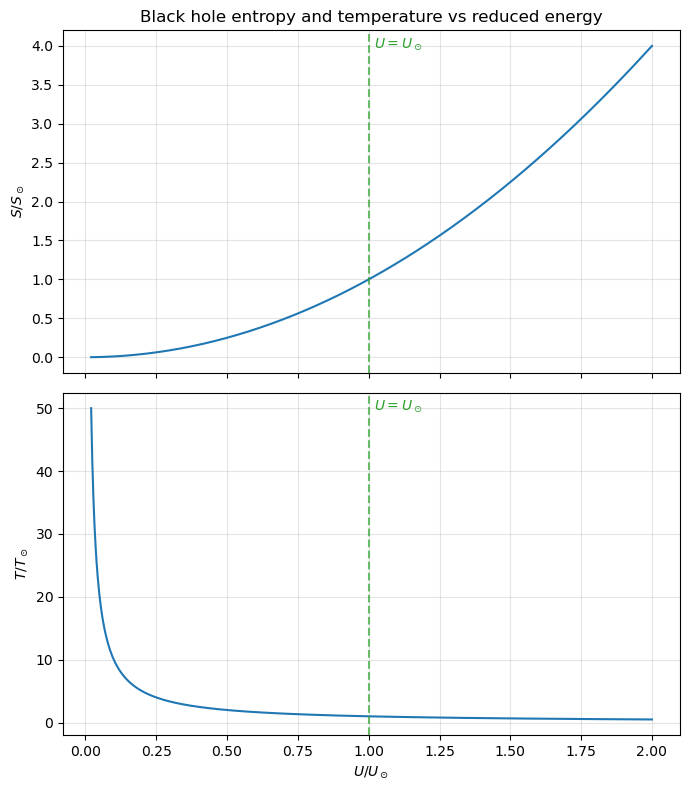

In [4]:
from numpy import linspace
from matplotlib.pyplot import subplots, show

s0, t0, u0 = hawkingEntropy(M_sun), hawkingTemperature(M_sun), M_sun*c**2
u = linspace(1/50*u0, 2*u0, 500)
s, t = hawkingEntropy(u/c**2), hawkingTemperature(u/c**2)

fig, ax = subplots(2, 1, sharex=True, tight_layout=True)
fig.set_figheight(8), fig.set_figwidth(7)
ax[0].plot(u/u0, s/s0), ax[0].set_ylabel(r'$S/S_\odot$')
ax[0].text(
    51/50, 19/20, r'$U=U_\odot$', 
    transform=ax[0].get_xaxis_transform(), color='C2')
ax[0].set_title(r'Black hole entropy and temperature vs reduced energy')
ax[0].axvline(1, linestyle='--', alpha=0.7, color='C2'), ax[0].grid(alpha=1/3)
ax[1].plot(u/u0, t/t0), ax[1].set_ylabel(r'$T/T_\odot$')
ax[1].set_xlabel(r'$U/U_\odot$')
ax[1].text(
    51/50, 19/20, r'$U=U_\odot$',
    transform=ax[1].get_xaxis_transform(), color='C2')
ax[1].axvline(1, linestyle='--', alpha=0.7, color='C2'), ax[1].grid(alpha=1/3)

show()

## Hawking radiation

A black hole is a blackbody if there ever was one, so it should emit blackbody
radiation, called Hawking radiation.  A black hole of mass $M$ has a total
energy of $Mc^2$, a surface area of $\frac{16\pi G^2 M^2}{c^4}$, and a
temperature of $\frac{hc^3}{16\pi^2 k_\text{B}GM}$.

### (A)

Show that the surface area expression really does have units of area.

$$
A = \frac{16\pi G^2 M^2}{c^4}
$$

$$
\left.\begin{aligned}\
  [G] &= \text{m}^{3} \cdot \text{kg}^{-1} \cdot \text{s}^{-2} \\
  [M] &= \text{kg} \\
  [c] &= \text{m} \cdot \text{s}^{-1}
\end{aligned}\right\}\Rightarrow  \boxed{[A] = 
\left[\frac{G^2 M^2}{c^4}\right]
= \frac{\text{m}^{6}\cdot\text{s}^{-4}}{\text{m}^{4} \cdot \text{s}^{-4}}
= \text{m}^2}
$$

### (B)

Estimate the typical wavelength of Hawking radiation emitted by a one-solar-mass
black hole. Compare your answer to the size of the black hole.

In [5]:
def hawkingWavelength(temperature):
    ''' typical wavelength emitted from black hole '''
    return h*c/(k_B*T)

T = hawkingTemperature(M_sun)
T_tex = sci_tex(T.value, 'K')

l = hawkingWavelength(T)
l_tex = sci_tex(l.value, 'm')

display(Markdown(
  r'''$$
  \left.\begin{aligned}M = %s \end{aligned}\right.
  \Rightarrow\left\{\begin{aligned}
      \lambda \sim \frac{hc}{k_\text{B} T}
      = \frac{hc}{k_\text{B}} \frac{16\pi^2 k_\text{B} G M}{hc^3}
      &= \frac{16\pi^2 G M}{c^2}
      = \frac{16\pi^2 G}{c^2} M_\odot 
      \\ &\approx \boxed{%s} 
  \end{aligned}\right. $$ ''' % (M_tex, l_tex)))

display(Markdown(
    r'''$$
      r_s \approx %s \lt %s \approx \lambda
    $$''' %(r_tex, l_tex)))

$$
  \left.\begin{aligned}M = M_\odot &\approx 1.988\times 10^{30}\,\mathrm{kg} \end{aligned}\right.
  \Rightarrow\left\{\begin{aligned}
      \lambda \sim \frac{hc}{k_\text{B} T}
      = \frac{hc}{k_\text{B}} \frac{16\pi^2 k_\text{B} G M}{hc^3}
      &= \frac{16\pi^2 G M}{c^2}
      = \frac{16\pi^2 G}{c^2} M_\odot 
      \\ &\approx \boxed{2.332\times 10^{5}\,\mathrm{m}} 
  \end{aligned}\right. $$ 

$$
      r_s \approx 2.953\times 10^{3}\,\mathrm{m} \lt 2.332\times 10^{5}\,\mathrm{m} \approx \lambda
    $$

### (C)

Imagine a black hole in empty space, where it emits radiation but absorbs
nothing. As it loses energy, its mass must decrease: one could say it
"evaporates". Use the intensity of blackbody radiation to derive a differential
equation for the mass as a function of time, and solve this equation to obtain
an expression for the lifetime of a black hole in terms of its initial mass.

$$
  \left.\begin{aligned}
    A &= \frac{16\pi G^2 M^2}{c^4} \\
    \sigma_\text{SB} &= \frac{2\pi^5 k_\text{B}^4}{15 h^3 c^2}\\
    T &= \frac{hc^3}{16\pi^2 k_\text{B} GM}
  \end{aligned}\right\}\Rightarrow\left\{ \begin{aligned}
    P &= A\sigma_\text{SB} T^4 \\
    &= \frac{16\pi G^2 M^2}{c^4}
    \cdot\frac{2\pi^5 k_\text{B}^4}{15 h^3 c^2}\cdot
    \left(\frac{hc^3}{16\pi^2 k_\text{B}GM}\right)^4  \\
    &= {\frac{hc^6}{15\cdot 2^{11}\pi^2 G^2 M^2}}
  \end{aligned}\right.
$$
$$
  U = Mc^2 
  \Rightarrow \left\{\begin{aligned}
    \frac{d}{dt}U &= -P \\
            c^2\frac{d}{dt}{M} &= -A\sigma_\text{SB} T^4 
    \\                         &= -\frac{hc^6}{15 \cdot 2^{11}\pi^2G^2 M^2 }
    \\         \frac{d}{dt}{M} &= -\frac{hc^4}{15\cdot 2^{11}\pi^2G^2}{M^{-2}}
  \end{aligned}\right\}\Rightarrow\left\{\begin{aligned}
    \\ \int_{M_0}^{M_t} M^2 dM &= -\int_0^t
                                   \frac{hc^4}{15\cdot 2^{11}\pi^2G^2}dt
    \\ \frac{M_t^3 - M_0^3}{3} &= -\frac{hc^4}{15 \cdot 2^{11}\pi^2G^2} t
    \\ M_t &= \sqrt[3]{M_0^3 - \frac{hc^4}{5 \cdot 2^{11}\pi^2 G^2} t}
  \end{aligned}\right.
$$
$$
  \left.\begin{aligned}
    0 &= M_\tau
    \\ \frac{c^4 h}{5 \cdot 2^{11}\pi^2 G^2} \tau_{M_0}  &= M_0^3
  \end{aligned}\right\}\Rightarrow\boxed{
    \tau_{M_0}  = \frac{5 \cdot 2^{11}\pi^2 G^2}{hc^4} M_0^3
    }
$$    

### (D)

Calculate the lifetime of a one-solar-mass black hole.

In [6]:
from astropy.cosmology import WMAP9
from scipy.constants import kilo, mega, parsec, day, year

def hawkingLifetime(initial_mass):
    ''' lifetime of blackhole from initial mass '''
    return 5*2**11 * pi**2 * G**2 * initial_mass**3 / (h*c**4)

tau, age_of_universe = hawkingLifetime(M_sun), mega*parsec/(kilo*WMAP9.H(0))

tau_tex = sci_tex(tau.value, 's')
tau_day_tex = sci_tex(tau.value/day, 'days')
tau_year_tex = sci_tex(tau.value/year, 'years')
t0_tex = sci_tex(age_of_universe.value, 's')

display(Markdown(
  r'''$$
  \left.\begin{aligned}
    M_0 = %s
  \end{aligned}\right.
  \Rightarrow\left\{\begin{aligned}
      \tau_{M_0}  &= \frac{5 \cdot 2^{11}\pi^2 G^2}{hc^4} M_0^3
      = \frac{5 \cdot 2^{11}\pi^2 G^2}{hc^4} M_\odot^3
      \\ &\approx \boxed{%s \approx %s} 
  \end{aligned}\right. $$ ''' % (M_tex, tau_day_tex, tau_year_tex)))

display(Markdown(
  r'''$$
    \text{age of universe} = \frac{1}{H_0} \approx %s
    \ll %s \approx \tau_{M_0}
  $$ ''' % (t0_tex, tau_tex)))

$$
  \left.\begin{aligned}
    M_0 = M_\odot &\approx 1.988\times 10^{30}\,\mathrm{kg}
  \end{aligned}\right.
  \Rightarrow\left\{\begin{aligned}
      \tau_{M_0}  &= \frac{5 \cdot 2^{11}\pi^2 G^2}{hc^4} M_0^3
      = \frac{5 \cdot 2^{11}\pi^2 G^2}{hc^4} M_\odot^3
      \\ &\approx \boxed{7.654\times 10^{69}\,\mathrm{days} \approx 2.097\times 10^{67}\,\mathrm{years}} 
  \end{aligned}\right. $$ 

$$
    \text{age of universe} = \frac{1}{H_0} \approx 4.451\times 10^{17}\,\mathrm{s}
    \ll 6.613\times 10^{74}\,\mathrm{s} \approx \tau_{M_0}
  $$ 

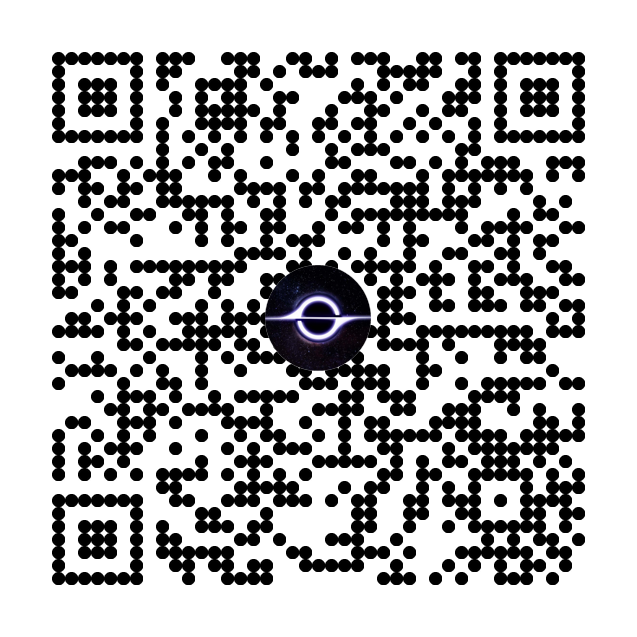

In [7]:
from qrcode import QRCode, constants
from qrcode.image.styledpil import StyledPilImage
from qrcode.image.styles.moduledrawers import CircleModuleDrawer
from PIL import Image

github_url = 'https://github.com/robo042/black_hole_thermodynamics/'

qr = QRCode(error_correction=constants.ERROR_CORRECT_H, box_size=13)
qr.add_data(github_url)
qr.make(fit=True)
img = qr.make_image(
    image_factory=StyledPilImage,
    module_drawer=CircleModuleDrawer(), eye_drawer=CircleModuleDrawer(), 
    fill_color='black', back_color='white').convert('RGBA')
logo_size = img.size[0]//6
logo = Image.open('assets/spacetime.png').resize((logo_size, logo_size))
pos = (img.size[0]//2 - logo_size//2, img.size[1]//2 - logo_size//2)
img.paste(logo, pos, mask=logo)
display(img)